In [1]:
import os
import datetime

import utils
import torch
import pandas as pd

from torch.utils.data import DataLoader

from cocodeel.dataset import CovarDataset
from cocodeel.model import BaseNetwork
from cocodeel.posthoc_model import PostHocLinearCovarNetwork

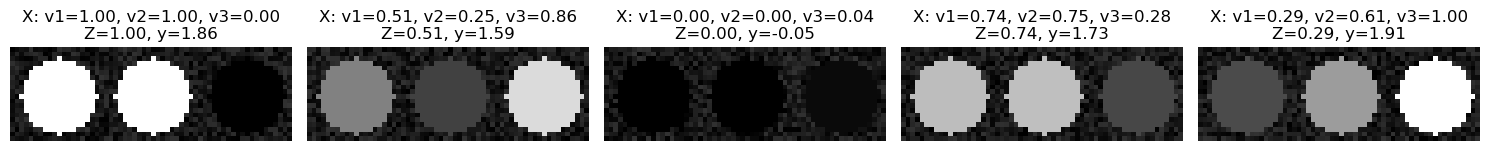

In [2]:
# Quick test run
X, Z, y, v1, v2, v3, fx, fz, fr = utils.simulate_traffic_light_data(n=5)
utils.show_samples(X, Z, v1, v2, v3, y, n_show=5)

In [3]:
def simulate_and_fit(seed=0):
    torch.manual_seed(seed)

    # Simulate data.
    X, Z, y, v1, v2, v3, fx, fz, fr = utils.simulate_traffic_light_data(seed=seed)
    N = X.shape[0]
    # Create training and validation.
    train_data = CovarDataset(X[:N // 2], Z[:N // 2], y[:N // 2])
    val_data = CovarDataset(X[N // 2:], Z[N // 2:], y[N // 2:])
    # Create dataloaders.
    train_loader = DataLoader(train_data, batch_size= N // 30, shuffle=True)
    val_loader = DataLoader(val_data, batch_size= N // 30, shuffle=False)

    # Train base DNN.
    base_model = utils.train_base_model(
        backbone=utils.TrafficBackbone,
        backbone_params={"out_features": 32},
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=100,
        lr=1e-3,
        weight_decay=1e-4,
        patience=8
    )
    base_model.center_features(train_loader)

    # Refit DNN to include control variables.
    posthoc_model = PostHocLinearCovarNetwork(base_model, num_covariates=Z.shape[1])
    posthoc_model.fit(dataloader=train_loader)

    # Return models.
    return base_model, posthoc_model

In [4]:
# Quick test simulate and fit
base_model, posthoc_model = simulate_and_fit(seed=0)

In [5]:
def run_experiment(name, n_runs=10):
    start_time = datetime.datetime.now()
    print(f"Starting experiment at {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
    experiment_name = f"{name}_nruns={n_runs}_{start_time.strftime('%Y%m%d-%H%M%S')}"
    out_dir = f"output/{experiment_name}"
    os.makedirs(out_dir, exist_ok=True)

    for run_id in range(n_runs):
        print(f"\tRun {run_id+1}/{n_runs} started at {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        base_model, posthoc_model = simulate_and_fit(seed=run_id)
        torch.save(base_model.state_dict(), f"{out_dir}/base_{run_id}.pth")
        torch.save(posthoc_model.state_dict(), f"{out_dir}/posthoc_{run_id}.pth")

    return experiment_name

In [6]:
# Quick test run experiment with n = 5.
experiment_name = run_experiment(name="traffic_light_test", n_runs=5)

Starting experiment at 2025-09-30 16:07:22
	Run 1/5 started at 2025-09-30 16:07:22
	Run 2/5 started at 2025-09-30 16:07:32
	Run 3/5 started at 2025-09-30 16:07:39
	Run 4/5 started at 2025-09-30 16:07:53
	Run 5/5 started at 2025-09-30 16:08:07


In [13]:
def evaluate_experiment(experiment_name):

    # Create test dataset.
    N = 10000
    X, Z, y, v1, v2, v3, fx, fz, fr = utils.simulate_traffic_light_data(n=N, seed=1234)

    # Grab directory contents.
    out_dir = f"output/{experiment_name}"
    model_files = [f for f in os.listdir(out_dir) if f.endswith(".pth")]
    n_runs = len(model_files) // 2
    print(f"Evaluating {n_runs} runs from experiment {experiment_name}")

    base_yhat = torch.zeros(size=(N, n_runs))
    base_fxhat = torch.zeros(size=(N, n_runs))
    posthoc_yhat = torch.zeros(size=(N, n_runs))
    posthoc_fxhat = torch.zeros(size=(N, n_runs))

    for run_id in range(n_runs):
        print(f"\tLoading and evaluating model {run_id+1}/{n_runs}.")

        # Load base model.
        model = BaseNetwork(backbone=utils.TrafficBackbone, backbone_params={"out_features": 32})
        base_model.load_state_dict(torch.load(f"{out_dir}/base_{run_id}.pth"))
        base_model.eval()

        # Load posthoc model.
        posthoc_model = PostHocLinearCovarNetwork(model, num_covariates=Z.shape[1])
        posthoc_model.load_state_dict(torch.load(f"{out_dir}/posthoc_{run_id}.pth"))
        posthoc_model.eval()

        # Evaluate models.
        base_yhat[:,run_id] = model(X, Z).squeeze().detach().cpu()
        base_fxhat[:,run_id] = model.fx(model.center_x(model.backbone(X))).squeeze().detach().cpu()
        posthoc_yhat[:,run_id] = posthoc_model(X, Z).squeeze().detach().cpu()
        posthoc_fxhat[:,run_id] = posthoc_model.fx(posthoc_model.center_x(posthoc_model.backbone(X))).squeeze().detach().cpu()

    # Compute metrics.
    results = {
        "base_y_mse": ((base_yhat - y)**2).mean(dim=0).numpy(),
        "base_fx_mse": ((base_fxhat - fx)**2).mean(dim=0).numpy(),
        "posthoc_y_mse": ((posthoc_yhat - y)**2).mean(dim=0).numpy(),
        "posthoc_fx_mse": ((posthoc_fxhat - fx)**2).mean(dim=0).numpy()
    }

    return results

In [14]:
# Quick test evaluate experiment.
results = evaluate_experiment(experiment_name)

Evaluating 5 runs from experiment traffic_light_test_nruns=5_20250930-160722
	Loading and evaluating model 1/5.
	Loading and evaluating model 2/5.
	Loading and evaluating model 3/5.
	Loading and evaluating model 4/5.
	Loading and evaluating model 5/5.


In [15]:
print(f"Base Model: \tMSE(y) = {results['base_y_mse'].mean():.4f} (± {results['base_y_mse'].std():.4f}), MSE(fx) = {results['base_fx_mse'].mean():.4f} (± {results['base_fx_mse'].std():.4f})")
print(f"PostHoc Model: \tMSE(y) = {results['posthoc_y_mse'].mean():.4f} (± {results['posthoc_y_mse'].std():.4f}), MSE(fx) = {results['posthoc_fx_mse'].mean():.4f} (± {results['posthoc_fx_mse'].std():.4f})")

Base Model: 	MSE(y) = 2.5959 (± 0.0349), MSE(fx) = 0.1229 (± 0.0026)
PostHoc Model: 	MSE(y) = 0.0110 (± 0.0003), MSE(fx) = 0.0576 (± 0.0334)
